<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/%EC%98%88%EC%83%81_%EB%B3%B4%EC%83%81%EA%B8%88_%EC%B6%94%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 사고 특성 기반 예상 보상금 추정

# 1. 라이브러리 설치 및 불러오기

- LightGBM과 CatBoost 모델을 사용하기 위한 프로그램 설치

- 라이브러리

pandas: 데이터 표 처리

numpy: 수치 계산

LightGBM: 보상금 예측 모델

CatBoost: 비교용 보상금 예측 모델

sklearn.metrics: 모델 성능 평가

In [1]:
!pip install -q lightgbm catboost koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 112.1 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    mean_squared_log_error
)

import lightgbm as lgb
from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor

pd.set_option("display.max_columns",100)
pd.set_option("display.float_format","{:,.2f}".format)

RANDOM_STATE = 42

# 2. 보상 데이터 불러오기

- 2021~2025년 보상 데이터를 하나로 합치는 과정

- 보상 데이터 안에는 학교급, 사고시간, 사고장소, 사고부위, 사고형태, 사고 당시 활동, 실제 지급된 보상금이 모두 포함되어 있기 때문에, 별도로 사고 데이터와 병합하지 않아도 된다.

- 데이터연도 추가

각 사고가 어느 연도 시트에서 왔는지를 기록하는 과정

기존 df_compensation에는 연도 정보가 사라져 있으므로, 모델링에서는 연도 시트를 다시 읽으며 데이터연도를 추가하는 것이 좋다.

In [5]:
# 보상 데이터 통합
# 각 연도 시트의 정보를 데이터연도로 보존

COMPENSATION_PATH="/content/★2021-2025 학교안전사고 보상 데이터.xlsx"
target_sheets=["2021","2022","2023","2024","2025"]

compensation_frames=[]

for year in target_sheets:
  temp=pd.read_excel(
      COMPENSATION_PATH,
      sheet_name=year,
      engine="openpyxl"
  )

  temp["데이터연도"]=int(year)
  compensation_frames.append(temp)

model_df=pd.concat(
    compensation_frames,
    ignore_index=True
)

print("모델링 데이터 크기:", model_df.shape)
display(model_df.head())

모델링 데이터 크기: (528503, 19)


,구분,지역,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,요양급여,장해급여,간병급여,유족급여,장례비,위로금,보전비용,데이터연도
0,F0000001,전남,고등학교,일반학생,2학년,남,쉬는시간,강당(체육관),골반/엉덩이,그밖의 손상 사고,기타,28000,0,0,0,0,0,0,2021
1,F0000002,경남,고등학교,일반학생,1학년,남,그 밖의 교육활동 시간,기타 교외,기타,그밖의 손상 사고,기타,0,0,15027000,0,0,0,0,2021
2,F0000003,광주,초등학교,일반학생,5학년,남,식사시간(간식 포함),일반(교과)교실,복부,그밖의 손상 사고,기타,1968000,0,0,0,0,0,0,2021
3,F0000004,전북,초등학교,일반학생,5학년,남,쉬는시간,일반(교과)교실,어깨,그밖의 손상 사고,기타,1600000,0,0,0,0,0,0,2021
4,F0000005,경북,초등학교,일반학생,1학년,남,체육,운동장,치아,고정된 물체와의 부딪힘,기타,10000,0,0,0,0,0,0,2021


# 3. 총보상액 생성

- 총보상액은 일곱 개 보상항목을 합산해서 만든다.

(요양급여+장해급여+간병급여+유족급여+장례비+위로급+보전비용)

- 보상금 데이터는 대부분 소액인데, 일부 사고는 수천만 원이나 수억 원이다. 거액의 사고가 모델에 매우 큰 영향을 주기에, 로그 변환을 시행하여 큰 값의 차이가 압축된다.

- 고액보상군 만들기

상위 1% 보상사고를 표시하는 변수로, '모델이 고액 사고도 잘 예측하는가?'를 별도로 확인하기 위해 생성한다.


In [16]:
# 타킷 변수 생성

compensation_cols=[
    "요양급여",
    "장해급여",
    "간병급여",
    "유족급여",
    "장례비",
    "위로금",
    "보전비용"
]

# 혹시 문자열로 얽힌 값이 있다면 숫자로 변환
for col in compensation_cols:
  model_df[col]=pd.to_numeric(
      model_df[col],
      errors="coerce"
  ).fillna(0)

# 총보상액 생성
model_df["총보상액"]=model_df[compensation_cols].sum(axis=1)

# 보상금 분포가 매우 오른쪽으로 치우쳐 있으므로 로그 변환
model_df["log총보상액"]=np.log1p(model_df["총보상액"])

print("총보상액 기초통계")
display(
    model_df["총보상액"].describe(
        percentiles=[0.50,0.75,0.90,0.95,0.99]
    ).to_frame()
)

# 상위 1%는 삭제하지않음
# 고액 보상군 표시
# 삭제 목적이 아니라 고액사고 성능 확인을 위한 변수

high_cost_threshold=model_df["총보상액"].quantile(0.99)

model_df["고액보상군"]=np.where(
    model_df["총보상액"]>=high_cost_threshold,
    1,
    0
)

print(f"고액 보상군 기준: {high_cost_threshold:,.0f}원")
print(model_df["고액보상군"].value_counts())


총보상액 기초통계


,총보상액
count,"528,503.00"
mean,"445,983.95"
std,"5,460,693.87"
min,"1,000.00"
50%,"114,000.00"
75%,"273,000.00"
90%,"822,000.00"
95%,"1,494,000.00"
99%,"3,351,000.00"
max,"1,010,000,000.00"


고액 보상군 기준: 3,351,000원
고액보상군
0    523212
1      5291
Name: count, dtype: int64


- 상위 1%는 오류값으로 단정할 수 없고, 가장 중요하게 관리해야 할 중대사고일 가능성이 크기 때문에 제거하지 않는다. 대신 로그 변환으로 영향력을 완화한다.

# 4. 입력변수와 타깃변수 선택

- 보상항목들은 총보상액을 직접 구성하므로 입력변수에 넣으면 안된다. 넣게 되면, 정답을 미리 알려주는 데이터 누수가 발생한다.

데이터 누수: 요양급여, 장해급여, 간병급여, 총보상액, log총보상액을 입력변수에 넣으면, 정답을 미리 알려주는거라 모델의 의미가 없어진다.

- 범주형 변수 지정

학교급, 사고형태, 사고장소 등

- model_data로 모델에 필요한 열만 따로 모아준다.

In [19]:
# 사용할 변수 지정

feature_cols=[
    "지역",
    "학교급",
    "사고자구분",
    "사고자학년",
    "사고자성별",
    "사고시간",
    "사고장소",
    "사고부위",
    "사고형태",
    "사고당시활동",
    "데이터연도"
]

categorical_cols=[
    "지역",
    "학교급",
    "사고자구분",
    "사고자학년",
    "사고자성별",
    "사고시간",
    "사고장소",
    "사고부위",
    "사고형태",
    "사고당시활동",
]

numerical_cols=["데이터연도"]

target_col="log총보상액"

# 필요한 칼럼만 추출
model_data=model_df[
    ["구분"]+feature_cols+
     ["총보상액","log총보상액","고액보상군"]
].copy()

# 범주형 변수 결측값 및 자료형 정리
for col in categorical_cols:
  model_data[col]=(
      model_data[col]
      .fillna("미상")
      .astype(str)
      .str.strip()
  )

model_data["데이터연도"]=pd.to_numeric(
    model_data["데이터연도"],
    errors="coerce"
)

model_data=model_data.dropna(
    subset=["데이터연도","총보상액","log총보상액"]
).reset_index(drop=True)

print("최종 모델링 데이터 크기:", model_data.shape)
print("\n입력변수별 고유값 수")
display(
    model_data[feature_cols]
    .nunique()
    .to_frame(name="고유값 수")
    )

최종 모델링 데이터 크기: (528503, 15)

입력변수별 고유값 수


,고유값 수
지역,17
학교급,6
사고자구분,3
사고자학년,7
사고자성별,2
사고시간,33
사고장소,48
사고부위,33
사고형태,29
사고당시활동,60


# 5. 학습/검증/테스트 데이터 분리

과거 데이터로 미래 데이터 예측하기

학습: 2021~2023년 (사고 패턴 학습)

검증: 2024년 (모델 설정이 적절한지 확인)

최종 테스트: 2025년

- x = 사고 특성

y =  실제 보상금

In [21]:
# 연도 기준 데이터 분리

train_df=model_data[
    model_data["데이터연도"].isin([2021,2022,2023])
].copy()

valid_df=model_data[
    model_data["데이터연도"]==2024
].copy()

test_df=model_data[
    model_data["데이터연도"]==2025
].copy()

print("학습 데이터:", train_df.shape)
print("검증 데이터:", valid_df.shape)
print("테스트 데이터:", test_df.shape)

X_train_raw=train_df[feature_cols].copy()
X_valid_raw=valid_df[feature_cols].copy()
X_test_raw=test_df[feature_cols].copy()

y_train=train_df[target_col].copy()
y_valid=valid_df[target_col].copy()
y_test=test_df[target_col].copy()

y_test_original=test_df["총보상액"].copy()

학습 데이터: (252592, 15)
검증 데이터: (132016, 15)
테스트 데이터: (143895, 15)


# 6. LightGBM용 범주형 데이터 처리

- OrdinalEncoder

LightGBM이 글자를 바로 처리할 때 오류가 생길 수 있으므로 숫자로 변환해준다.

- LightGBM은 pandas의 category 자료형을 통해 범주형 변수를 인식할 수 있다.

- 검증/테스트 데이터에서 학습 데이터에 없던 새로운 범주가 등장할 수 있으므로 미상_범주로 처리한다.

In [32]:
# LightGBM용 데이터 전처리
# OrdinalEncoder로 범주형 변수를 동일한 숫자로 변환
import numpy as np
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
import lightgbm as lgb

X_train_lgb = X_train_raw.copy()
X_valid_lgb = X_valid_raw.copy()
X_test_lgb = X_test_raw.copy()

for col in categorical_cols:
    X_train_lgb[col] = X_train_lgb[col].fillna("미상").astype(str)
    X_valid_lgb[col] = X_valid_lgb[col].fillna("미상").astype(str)
    X_test_lgb[col] = X_test_lgb[col].fillna("미상").astype(str)

ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.int32
)

X_train_lgb[categorical_cols] = ordinal_encoder.fit_transform(
    X_train_lgb[categorical_cols]
)

X_valid_lgb[categorical_cols] = ordinal_encoder.transform(
    X_valid_lgb[categorical_cols]
)

X_test_lgb[categorical_cols] = ordinal_encoder.transform(
    X_test_lgb[categorical_cols]
)

for df in [X_train_lgb, X_valid_lgb, X_test_lgb]:
    df["데이터연도"] = pd.to_numeric(
        df["데이터연도"],
        errors="coerce"
    )

year_median = X_train_lgb["데이터연도"].median()

X_train_lgb["데이터연도"] = X_train_lgb["데이터연도"].fillna(year_median)
X_valid_lgb["데이터연도"] = X_valid_lgb["데이터연도"].fillna(year_median)
X_test_lgb["데이터연도"] = X_test_lgb["데이터연도"].fillna(year_median)

print("LightGBM 전처리 완료")
print("학습 데이터:", X_train_lgb.shape)
print("검증 데이터:", X_valid_lgb.shape)
print("테스트 데이터:", X_test_lgb.shape)

display(X_train_lgb.head())
print(X_train_lgb.dtypes)

LightGBM 전처리 완료
학습 데이터: (252592, 11)
검증 데이터: (132016, 11)
테스트 데이터: (143895, 11)


,지역,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,데이터연도
0,12,0,0,1,0,15,2,0,7,5,2021
1,2,0,0,0,0,3,21,2,7,5,2021
2,4,4,0,4,0,16,37,15,7,5,2021
3,13,4,0,4,0,15,37,23,7,5,2021
4,3,4,0,0,0,28,36,27,4,5,2021


지역        int32
학교급       int32
사고자구분     int32
사고자학년     int32
사고자성별     int32
사고시간      int32
사고장소      int32
사고부위      int32
사고형태      int32
사고당시활동    int32
데이터연도     int64
dtype: object


In [33]:
categorical_indices = [
    X_train_lgb.columns.get_loc(col)
    for col in categorical_cols
]

RANDOM_STATE = 42

lgb_model = LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_valid_lgb, y_valid)],
    eval_metric="rmse",
    categorical_feature=categorical_indices,
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        lgb.log_evaluation(period=100)
    ]
)

print("LightGBM 최적 반복 횟수:", lgb_model.best_iteration_)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 1.17356	valid_0's l2: 1.37725
[200]	valid_0's rmse: 1.16645	valid_0's l2: 1.3606
[300]	valid_0's rmse: 1.16447	valid_0's l2: 1.356
[400]	valid_0's rmse: 1.16352	valid_0's l2: 1.35377
[500]	valid_0's rmse: 1.16301	valid_0's l2: 1.3526
[600]	valid_0's rmse: 1.16275	valid_0's l2: 1.352
[700]	valid_0's rmse: 1.16249	valid_0's l2: 1.35138
[800]	valid_0's rmse: 1.16231	valid_0's l2: 1.35097
[900]	valid_0's rmse: 1.16229	valid_0's l2: 1.35091
[1000]	valid_0's rmse: 1.16229	valid_0's l2: 1.35091
Early stopping, best iteration is:
[967]	valid_0's rmse: 1.16223	valid_0's l2: 1.35077
Evaluated only: rmse
LightGBM 최적 반복 횟수: 967


# 7. LightGBM Regressor 학습

- 직접 규칙을 입력하는 것이 아닌, 모델이 데이터에서 규칙을 찾는 과정.

- 조기 종료 과정

LightGBM이 최대 3000번 학습하도록 설정했지만, 성능 개선이 없을 시 조기 종료

In [34]:
# LightGBM Regressor 학습

RANDOM_STATE = 42

lgb_model = LGBMRegressor(
    objective="regression",
    metric="rmse",

    # 학습 속도와 성능 관련
    n_estimators=3000,
    learning_rate=0.03,

    # 트리 복잡도
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    # 과적합 방지
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=0.5,

    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train_lgb,
    y_train,

    eval_set=[
        (X_valid_lgb, y_valid)
    ],

    eval_metric="rmse",

    categorical_feature=categorical_indices,

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        lgb.log_evaluation(period=100)
    ]
)

print(
    "LightGBM 최적 반복 횟수:",
    lgb_model.best_iteration_
)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 1.17356
[200]	valid_0's rmse: 1.16645
[300]	valid_0's rmse: 1.16447
[400]	valid_0's rmse: 1.16352
[500]	valid_0's rmse: 1.16301
[600]	valid_0's rmse: 1.16275
[700]	valid_0's rmse: 1.16249
[800]	valid_0's rmse: 1.16231
[900]	valid_0's rmse: 1.16229
[1000]	valid_0's rmse: 1.16229
Early stopping, best iteration is:
[967]	valid_0's rmse: 1.16223
Evaluated only: rmse
LightGBM 최적 반복 횟수: 967


# 8. CatBoost용 데이터 준비

- CatBoost에서는 범주형 값을 문자열로 유지한 채 범주형 컬럼 이름을 지정한다.

- 범주형 변수가 많은 데이터 특성을 고려하여 LightGBM과 CatBoost의 성능을 비교한다.

In [35]:
# CatBoost용 데이터 준비

X_train_cat=X_train_raw.copy()
X_valid_cat=X_valid_raw.copy()
X_test_cat=X_test_raw.copy()

for col in categorical_cols:
  X_train_cat[col]=X_train_cat[col].fillna("미상").astype(str)
  X_valid_cat[col]=X_valid_cat[col].fillna("미상").astype(str)
  X_test_cat[col]=X_test_cat[col].fillna("미상").astype(str)

# 9. CatBoost Regressor 학습

CatBoostRegressor는 scikit-learn 형태의 회귀 인터페이스를 지원하며,
cat_features로 범주형 변수의 이름이나 인덱스를 전달할 수 있다.

In [40]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",

    # 실행시간 단축
    iterations=1200,
    learning_rate=0.07,
    depth=7,

    # 과적합 방지
    l2_leaf_reg=5,
    random_strength=1,

    random_seed=RANDOM_STATE,

    # 검증 성능이 50회 동안 개선되지 않으면 종료
    od_type="Iter",
    od_wait=50,

    # CPU 사용
    thread_count=-1,

    allow_writing_files=False,
    verbose=100
)

cat_model.fit(
    X_train_cat,
    y_train,

    cat_features=categorical_cols,

    eval_set=(X_valid_cat, y_valid),

    use_best_model=True
)

print("CatBoost 최적 반복 횟수:", cat_model.get_best_iteration())
print("CatBoost 최적 검증 점수:", cat_model.get_best_score())



0:	learn: 1.2760730	test: 1.2807132	best: 1.2807132 (0)	total: 587ms	remaining: 11m 43s
100:	learn: 1.1461286	test: 1.1738755	best: 1.1738755 (100)	total: 49.1s	remaining: 8m 53s
200:	learn: 1.1388336	test: 1.1692311	best: 1.1692311 (200)	total: 1m 40s	remaining: 8m 19s
300:	learn: 1.1354826	test: 1.1676483	best: 1.1676483 (300)	total: 2m 33s	remaining: 7m 38s
400:	learn: 1.1329352	test: 1.1668326	best: 1.1668326 (399)	total: 3m 27s	remaining: 6m 52s
500:	learn: 1.1306975	test: 1.1662968	best: 1.1662959 (499)	total: 4m 21s	remaining: 6m 4s
600:	learn: 1.1288915	test: 1.1659314	best: 1.1659254 (599)	total: 5m 15s	remaining: 5m 13s
700:	learn: 1.1270466	test: 1.1655783	best: 1.1655783 (700)	total: 6m 10s	remaining: 4m 23s
800:	learn: 1.1253832	test: 1.1654107	best: 1.1653946 (794)	total: 7m 5s	remaining: 3m 32s
900:	learn: 1.1239964	test: 1.1652083	best: 1.1652083 (900)	total: 7m 59s	remaining: 2m 39s
1000:	learn: 1.1225435	test: 1.1650462	best: 1.1650361 (993)	total: 8m 55s	remaining: 1

# 10. 예측값 생성

모델은 로그 보상액을 예측했으므로 expm1()로 원 단위 금액으로 복원한다.

In [42]:
# 테스트 데이터 예측

# 로그 단위 예측
lgb_pred_log=lgb_model.predict(
    X_test_lgb,
    num_iteration=lgb_model.best_iteration_
)

cat_pred_log=cat_model.predict(X_test_cat)

# 원 단위로 복원
lgb_pred_amount=np.expm1(lgb_pred_log)
cat_pred_amount=np.expm1(cat_pred_log)

# 음수 예측 방지
lgb_pred_amount=np.clip(lgb_pred_amount, 0, None)
cat_pred_amount=np.clip(cat_pred_amount, 0, None)

# 11. 평가 함수

MAE는 실제 금액 기준 평균 오차, RMSE는 큰 오차에 더 민감한 지표다. R^2는 1에 가까울수록 설명력이 높고 음수가 나올 수도 있다.

- MAE: 평균적으로 실제 보상액과 몇 원 정도 차이가 나는지

- RMSE: 초고액 사고를 크게 틀렸을 때 더 큰 불이익을 주는 지표

- 중앙절대오차: 오차들의 중앙값

: 일부 초고액 사고의 영향을 줄인 일반적인 오차

: 고액 사고 몇 건 때문에 평균이 크게 흔들리는 것을 보완

_ R^2(log): 로그 보상액의 변동을 모델이 얼마나 설명하는지

- 0.5~2배 이내 비율: 예측이 실제 금액의 절반에서 두 배 사이에 들어온 비율

In [44]:
# 모델 평가 함수

def evaluate_regression_model(
    model_name,
    y_true_amount,
    y_true_log,
    pred_amount,
    pred_log
):

    mae = mean_absolute_error(
        y_true_amount,
        pred_amount
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true_amount,
            pred_amount
        )
    )

    median_ae = median_absolute_error(
        y_true_amount,
        pred_amount
    )

    r2_original = r2_score(
        y_true_amount,
        pred_amount
    )

    rmse_log = np.sqrt(
        mean_squared_error(
            y_true_log,
            pred_log
        )
    )

    r2_log = r2_score(
        y_true_log,
        pred_log
    )

    # 실제값의 0.5~2배 범위 안에 있는 비율
    true_safe = np.maximum(
        np.asarray(y_true_amount),
        1
    )

    ratio = pred_amount / true_safe

    within_factor_2 = np.mean(
        (ratio >= 0.5) & (ratio <= 2.0)
    ) * 100

    return {
        "모델": model_name,
        "MAE(원)": mae,
        "RMSE(원)": rmse,
        "중앙절대오차(원)": median_ae,
        "R2(원본)": r2_original,
        "RMSE(log)": rmse_log,
        "R2(log)": r2_log,
        "실제금액 0.5~2배 이내(%)": within_factor_2
    }


# 모델 평가
lgb_metrics = evaluate_regression_model(
    model_name="LightGBM",
    y_true_amount=y_test_original,
    y_true_log=y_test,
    pred_amount=lgb_pred_amount,
    pred_log=lgb_pred_log
)

cat_metrics = evaluate_regression_model(
    model_name="CatBoost",
    y_true_amount=y_test_original,
    y_true_log=y_test,
    pred_amount=cat_pred_amount,
    pred_log=cat_pred_log
)

metrics_df = pd.DataFrame([
    lgb_metrics,
    cat_metrics
])

display(
    metrics_df.style.format({
        "MAE(원)": "{:,.0f}",
        "RMSE(원)": "{:,.0f}",
        "중앙절대오차(원)": "{:,.0f}",
        "R2(원본)": "{:.4f}",
        "RMSE(log)": "{:.4f}",
        "R2(log)": "{:.4f}",
        "실제금액 0.5~2배 이내(%)": "{:.2f}"
    })
)

,모델,MAE(원),RMSE(원),중앙절대오차(원),R2(원본),RMSE(log),R2(log),실제금액 0.5~2배 이내(%)
0,LightGBM,"367,942","5,273,205","73,162",0.0004,1.1837,0.1837,48.27
1,CatBoost,"368,141","5,273,759","73,080",0.0002,1.1860,0.1805,48.26


# 12. 단순 기준 모델과 비교

머신러닝 모델이 의미가 있으려면 모든 사고에 학습 데이터 중아값을 예측하는 단순 모델보다 좋아야 한다.

In [45]:
# 기존 모델 baseline

baseline_log=np.repeat(
    y_train.median(),
    len(y_test)
)

baseline_amount=np.expm1(baseline_log)

baseline_metrics=evaluate_regression_model(
    model_name="Baseline(학습 중앙값)",
    y_true_amount=y_test_original,
    y_true_log=y_test,
    pred_amount=baseline_amount,
    pred_log=baseline_log
)

comparison_df=pd.DataFrame([
    baseline_metrics,
    lgb_metrics,
    cat_metrics
])

display(
    comparison_df.style.format({
        "MAE(원)": "{:,.0f}",
        "RMSE(원)": "{:,.0f}",
        "중앙절대오차(원)": "{:,.0f}",
        "R2(원본)": "{:.4f}",
        "RMSE(log)": "{:.4f}",
        "R2(log)": "{:.4f}",
        "실제금액 0.5~2배 이내(%)": "{:.2f}"
    })
)

,모델,MAE(원),RMSE(원),중앙절대오차(원),R2(원본),RMSE(log),R2(log),실제금액 0.5~2배 이내(%)
0,Baseline(학습 중앙값),"383,522","5,284,692","71,000",-0.0039,1.3239,-0.0213,46.77
1,LightGBM,"367,942","5,273,205","73,162",0.0004,1.1837,0.1837,48.27
2,CatBoost,"368,141","5,273,759","73,080",0.0002,1.1860,0.1805,48.26


- RMSE(log) 감소

- R^2가 음수 -> 양수로 증가

- 예측 정확도도 약간 상승

-> 평균만 예측하는 모델보다 훨씬 정확하게 보상금을 예측할 수 있다.

# 13. 고액 보상 사고에 대한 성능 확인

전체 평균 성능이 좋아도 고액 중대사고를 전부 낮게 예측하면, 목적에 맞지 않고 어긋난다. 따라서 상위 10% 고액사고에서의 오차를 별도로 확인한다.

In [46]:
# ============================================================
# 16-16. 고액 사고 구간 성능 평가
# ============================================================

high_10_threshold = y_test_original.quantile(0.90)
high_mask = y_test_original >= high_10_threshold

high_cost_metrics = pd.DataFrame({
    "모델": ["LightGBM", "CatBoost"],

    "고액사고_MAE": [
        mean_absolute_error(
            y_test_original[high_mask],
            lgb_pred_amount[high_mask]
        ),
        mean_absolute_error(
            y_test_original[high_mask],
            cat_pred_amount[high_mask]
        )
    ],

    "고액사고_RMSE": [
        np.sqrt(
            mean_squared_error(
                y_test_original[high_mask],
                lgb_pred_amount[high_mask]
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test_original[high_mask],
                cat_pred_amount[high_mask]
            )
        )
    ],

    "고액사고_평균실제금액": [
        y_test_original[high_mask].mean(),
        y_test_original[high_mask].mean()
    ],

    "고액사고_평균예측금액": [
        lgb_pred_amount[high_mask].mean(),
        cat_pred_amount[high_mask].mean()
    ]
})

print(f"테스트 데이터 상위 10% 기준: {high_10_threshold:,.0f}원")

display(
    high_cost_metrics.style.format({
        "고액사고_MAE": "{:,.0f}",
        "고액사고_RMSE": "{:,.0f}",
        "고액사고_평균실제금액": "{:,.0f}",
        "고액사고_평균예측금액": "{:,.0f}"
    })
)

테스트 데이터 상위 10% 기준: 883,600원


,모델,고액사고_MAE,고액사고_RMSE,고액사고_평균실제금액,고액사고_평균예측금액
0,LightGBM,"2,642,831","16,665,633","2,924,500","286,301"
1,CatBoost,"2,644,871","16,667,420","2,924,500","283,521"


- LightGBM의 고액사고 MAE는 약 264만원, RMSE는 약 1665만원

- CatBoost의 고액사고 MAE는 약 264만원, RMSE는 약 1666만원

-> 상위 10%의 고액 보상 사고만 따로 평가한 결과, 예측 오차가 크게 증가하였다. 이는 중증사고는 발생 빈도가 매우 낮고 피해 규모의 변동성이 커 일반 사고보다 예측이 훨씬 어려움을 의미한다.

# 14. 모델 성능 비교 그래프


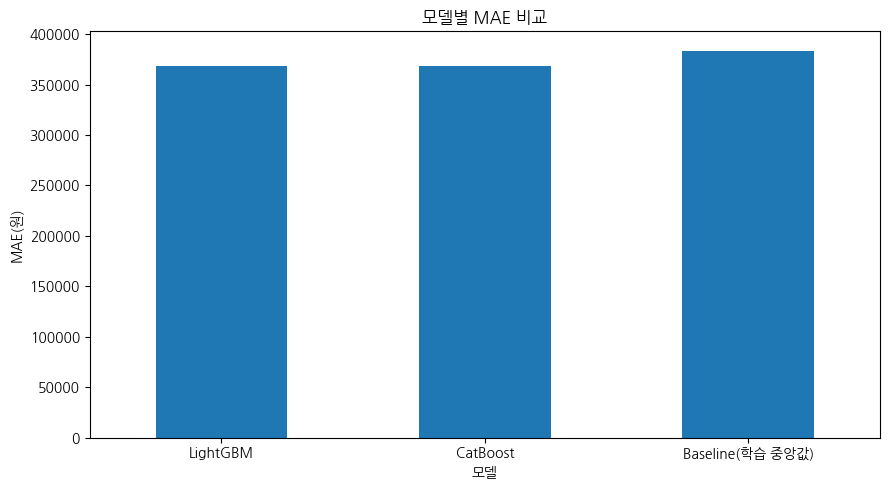

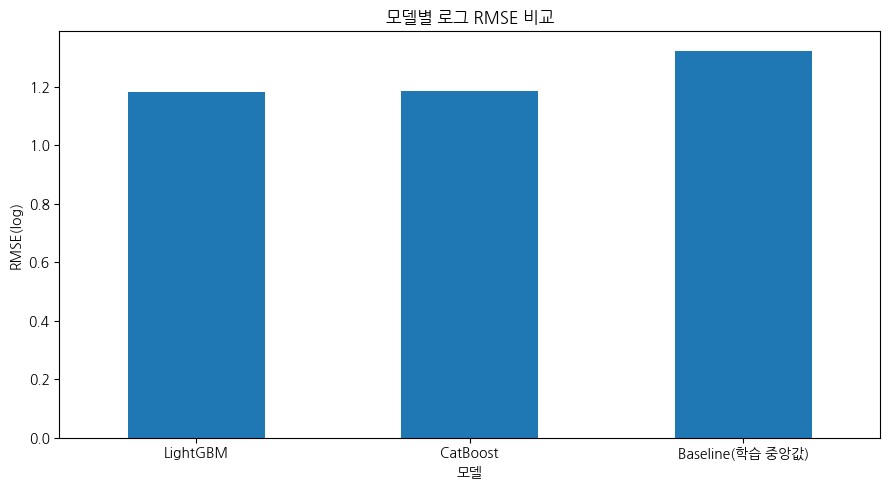

In [47]:
# 16-17. MAE 비교

plot_metrics = comparison_df.set_index("모델")

plt.figure(figsize=(9, 5))
plot_metrics["MAE(원)"].sort_values().plot(
    kind="bar"
)

plt.title("모델별 MAE 비교")
plt.xlabel("모델")
plt.ylabel("MAE(원)")
plt.xticks(rotation=0)
plt.ticklabel_format(
    style="plain",
    axis="y"
)
plt.tight_layout()
plt.show()


# 16-18. 로그 RMSE 비교
plt.figure(figsize=(9, 5))
plot_metrics["RMSE(log)"].sort_values().plot(
    kind="bar"
)

plt.title("모델별 로그 RMSE 비교")
plt.xlabel("모델")
plt.ylabel("RMSE(log)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- 첫 번째 그래프 (MAE)

LightGBM은 약 26.8만원, CatBoost는 약 36.8만원, Baseline은 약 38.3만원으로, 머신러닝 모델이 단순히 평균 보상금만 예측하는 모델보다 평균 오차를 약 1.5만원 정도 줄였다.

- 두 번째 그래프 (RMSE)

Baseline이 LightGBM, CatBoost보다 더 높다. 고액 사고처럼 큰 오차가 발생하는 경우까지 고려해도 머신러닝 모델이 더 안정적으로 에측하였다.

# 15. 실제값과 예측값 비교

데이터가 많으므로 테스트 데이터에서 최대 5000건만 표본으로 시각화한다.

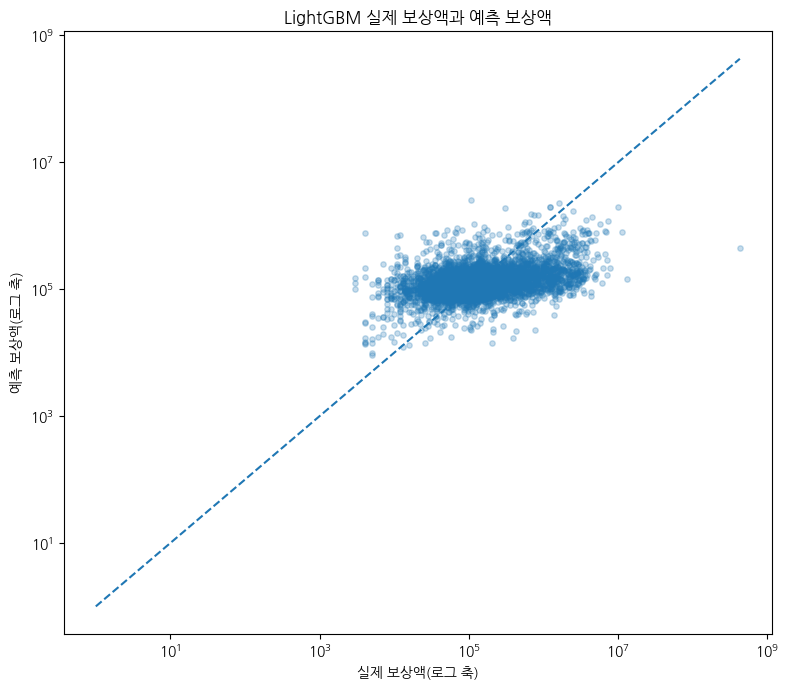

In [48]:
# ============================================================
# 16-19. 실제값과 예측값 산점도
# ============================================================

result_df = test_df[
    ["구분"] + feature_cols +
    ["총보상액", "고액보상군"]
].copy()

result_df["LightGBM_예측보상액"] = lgb_pred_amount
result_df["CatBoost_예측보상액"] = cat_pred_amount

sample_n = min(5000, len(result_df))

plot_sample = result_df.sample(
    n=sample_n,
    random_state=RANDOM_STATE
)

max_value = max(
    plot_sample["총보상액"].max(),
    plot_sample["LightGBM_예측보상액"].max()
)

plt.figure(figsize=(8, 7))

plt.scatter(
    plot_sample["총보상액"],
    plot_sample["LightGBM_예측보상액"],
    alpha=0.25,
    s=15
)

plt.plot(
    [1, max_value],
    [1, max_value],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")

plt.title("LightGBM 실제 보상액과 예측 보상액")
plt.xlabel("실제 보상액(로그 축)")
plt.ylabel("예측 보상액(로그 축)")
plt.tight_layout()
plt.show()

- 점들이 가운데로 몰려있는 상태를 띈다. 즉 모델이 평균 쪽으로 예측한다.

- 오른쪽 부분, 즉 고액 사고에서는 점들이 대각선보다 훨씬 아래에 있다. 즉, 고액 사고를 과소추정한다. (예측값이 실제값보다 낮게 나타나는 경향)

- 왼쪽 부분, 즉 실제 보상금이 작은 사고는 크게 예측하는 경향이 있다.

-> 소액의 사고는 몇십만 건, 거액의 사고는 몇백 건만 존재하는 데이터의 상태에 따라, 모델은 평균 근처로 예측한다.

# 16. 예측 구간별 보정 상태 확인

예측 보상액이 높은 집단일수록 실제 보상액도 높아지는지 확인한다.



In [49]:
# 16-20. 예측 금액 분위별 실제·예측 비교


def create_calibration_table(
    actual,
    predicted,
    model_name,
    n_bins=10
):
    temp = pd.DataFrame({
        "실제보상액": np.asarray(actual),
        "예측보상액": np.asarray(predicted)
    })

    temp["예측금액구간"] = pd.qcut(
        temp["예측보상액"],
        q=n_bins,
        duplicates="drop"
    )

    calibration = (
        temp.groupby(
            "예측금액구간",
            observed=True
        )
        .agg(
            사고건수=("실제보상액", "size"),
            평균실제보상액=("실제보상액", "mean"),
            중앙실제보상액=("실제보상액", "median"),
            평균예측보상액=("예측보상액", "mean")
        )
        .reset_index()
    )

    calibration["모델"] = model_name

    return calibration



In [50]:
lgb_calibration = create_calibration_table(
    y_test_original,
    lgb_pred_amount,
    "LightGBM"
)

cat_calibration = create_calibration_table(
    y_test_original,
    cat_pred_amount,
    "CatBoost"
)

display(lgb_calibration)
display(cat_calibration)

,예측금액구간,사고건수,평균실제보상액,중앙실제보상액,평균예측보상액,모델
0,"(5845.589, 73722.595]",14390,"131,341.49","58,000.00","56,370.14",LightGBM
1,"(73722.595, 87049.365]",14390,"234,846.14","80,000.00","80,763.79",LightGBM
2,"(87049.365, 98120.405]",14389,"234,914.94","89,000.00","92,584.37",LightGBM
3,"(98120.405, 109527.79]",14389,"293,428.24","98,000.00","103,734.25",LightGBM
4,"(109527.79, 122278.979]",14390,"249,222.52","107,000.00","115,887.21",LightGBM
5,"(122278.979, 137067.662]",14390,"330,783.60","120,000.00","129,433.46",LightGBM
6,"(137067.662, 155973.431]",14389,"352,221.49","135,000.00","146,128.01",LightGBM
7,"(155973.431, 184281.267]",14392,"445,855.61","155,500.00","169,173.79",LightGBM
8,"(184281.267, 244680.619]",14386,"732,986.24","185,000.00","209,155.07",LightGBM
9,"(244680.619, 3973393.96]",14390,"1,423,747.05","492,000.00","452,696.37",LightGBM


,예측금액구간,사고건수,평균실제보상액,중앙실제보상액,평균예측보상액,모델
0,"(4915.892, 75120.799]",14394,"124,519.38","59,000.00","57,197.03",CatBoost
1,"(75120.799, 88102.61]",14386,"184,664.26","79,000.00","81,987.52",CatBoost
2,"(88102.61, 98629.745]",14389,"280,559.04","89,000.00","93,408.85",CatBoost
3,"(98629.745, 109982.234]",14389,"268,468.34","98,000.00","104,249.94",CatBoost
4,"(109982.234, 122612.902]",14393,"265,327.03","108,000.00","116,116.34",CatBoost
5,"(122612.902, 137427.317]",14386,"310,823.09","119,000.00","129,736.20",CatBoost
6,"(137427.317, 156255.22]",14389,"355,554.94","135,000.00","146,367.77",CatBoost
7,"(156255.22, 183767.801]",14390,"519,102.85","156,000.00","168,912.50",CatBoost
8,"(183767.801, 240309.633]",14389,"702,818.61","182,000.00","206,827.72",CatBoost
9,"(240309.633, 4310804.536]",14390,"1,417,466.30","485,000.00","449,717.57",CatBoost


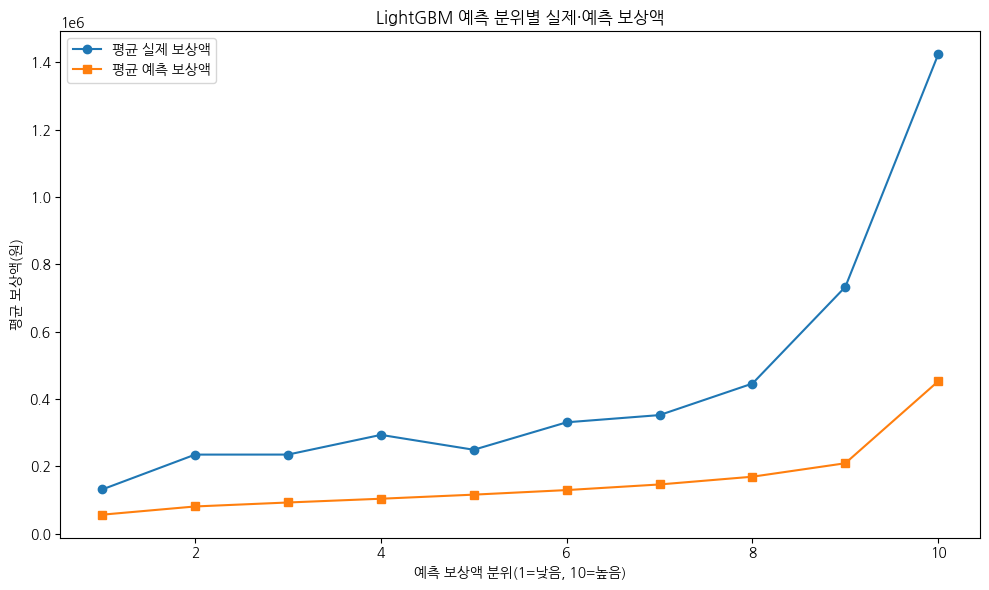

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(lgb_calibration) + 1),
    lgb_calibration["평균실제보상액"],
    marker="o",
    label="평균 실제 보상액"
)

plt.plot(
    range(1, len(lgb_calibration) + 1),
    lgb_calibration["평균예측보상액"],
    marker="s",
    label="평균 예측 보상액"
)

plt.title("LightGBM 예측 분위별 실제·예측 보상액")
plt.xlabel("예측 보상액 분위(1=낮음, 10=높음)")
plt.ylabel("평균 보상액(원)")
plt.legend()
plt.tight_layout()
plt.show()

- 예측 보상금이 증가할수록 실제 보상금도 함께 증가하는 경향을 보여 모델이 사고의 상대적인 위험 수준은 적절히 학습한 것으로 나타났다.

- 상위 예측 구간에서는 실제 평균 보상금이 예측 평균보다 크게 높게 나타나, 고액 보상 사고를 과소추정하는 경향이 확인되었다. 이는 고약 사고의 발생 빈도가 매우 낮고 피해 규모의 변동성이 커 학습이 어려웠기 때문으로 판단된다.

# 17. 변수 중요도 분석

"어떤 사고 특성이 예상 보상액 추정에 많이 사영되었는가"를 보여준다. 인과관계를 의미하지는 않고 모델 예측 기여도를 나타낸다.

In [52]:
# 16-21. LightGBM 변수 중요도
# gain 기준

lgb_importance = pd.DataFrame({
    "변수": lgb_model.booster_.feature_name(),
    "중요도": lgb_model.booster_.feature_importance(
        importance_type="gain"
    )
})

lgb_importance["중요도비율(%)"] = (
    lgb_importance["중요도"]
    / lgb_importance["중요도"].sum()
    * 100
)

lgb_importance = lgb_importance.sort_values(
    "중요도",
    ascending=False
).reset_index(drop=True)

display(lgb_importance)

,변수,중요도,중요도비율(%)
0,사고부위,"539,024.61",32.79
1,사고자학년,"234,568.05",14.27
2,학교급,"223,904.81",13.62
3,지역,"149,073.79",9.07
4,사고형태,"127,196.76",7.74
5,사고당시활동,"113,691.11",6.92
6,사고자구분,"86,318.04",5.25
7,사고시간,"82,256.28",5.00
8,사고장소,"54,305.81",3.30
9,사고자성별,"24,012.69",1.46


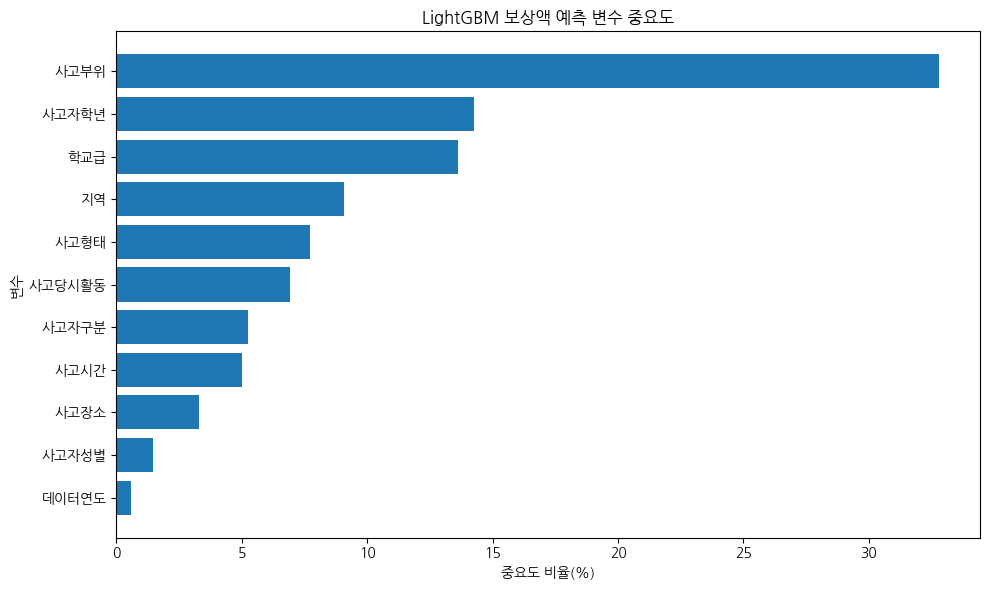

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(
    lgb_importance["변수"][::-1],
    lgb_importance["중요도비율(%)"][::-1]
)

plt.title("LightGBM 보상액 예측 변수 중요도")
plt.xlabel("중요도 비율(%)")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

- LightGBM 변수 중요도 분석 결과, 사고부위가 가장 중요한 변수로 나타났으며, 사고자학년, 학교급, 사고형태 등이 뒤를 이었다. 이는 동일한 사고라도 어느 부위를 다쳤는지와 학생의 발달 단계에 따라 피해 규모가 크게 달라짐을 의미한다.

# CatBoost 변수 중요도

In [54]:
# 16-22. CatBoost 변수 중요도

cat_importance = pd.DataFrame({
    "변수": feature_cols,
    "중요도": cat_model.get_feature_importance()
})

cat_importance["중요도비율(%)"] = (
    cat_importance["중요도"]
    / cat_importance["중요도"].sum()
    * 100
)

cat_importance = cat_importance.sort_values(
    "중요도",
    ascending=False
).reset_index(drop=True)

display(cat_importance)


,변수,중요도,중요도비율(%)
0,사고부위,25.93,25.93
1,사고자학년,15.43,15.43
2,학교급,14.71,14.71
3,사고형태,9.46,9.46
4,사고자구분,9.26,9.26
5,지역,8.28,8.28
6,사고당시활동,4.90,4.90
7,사고시간,3.61,3.61
8,사고장소,3.07,3.07
9,사고자성별,2.97,2.97


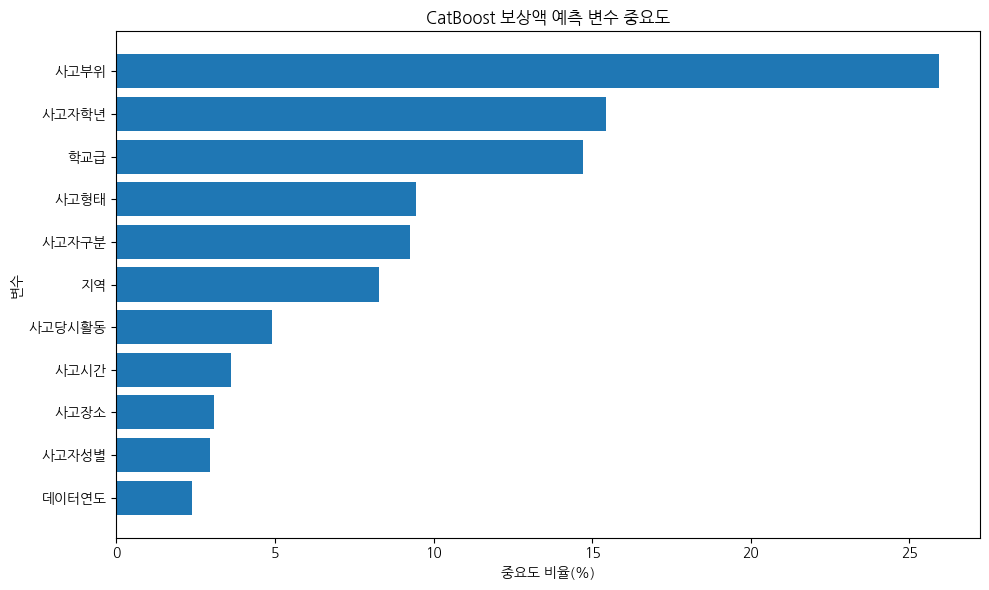

In [55]:
plt.figure(figsize=(10, 6))

plt.barh(
    cat_importance["변수"][::-1],
    cat_importance["중요도비율(%)"][::-1]
)

plt.title("CatBoost 보상액 예측 변수 중요도")
plt.xlabel("중요도 비율(%)")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

- LightGBM과 CatBoost 모두 사고부위를 가장 중요한 변수로 판단하였다. 또한 사고자학년, 학교급, 사고형태 역시 공통적으로 높은 중요도를 보여, 보상금 규모는 사고의 발생 장소보다 부상의 정도와 학생 특성의 영향을 더 크게 받는 것으로 나타났다.

- LightGBM은 지역도 꽤 참고하였고, CatBoost는 사고형태를 조금 더 많이 사용하였다.

# 18. 고액 보상이 예상되는 사고 추출

- 두 모델 중 성능이 더 좋은 모델을 자동으로 선택한다. 기준은 로그 RMSE가 더 낮은 모델이다.

In [56]:
# 16-23. 최종 모델 자동 선택

if lgb_metrics["RMSE(log)"] <= cat_metrics["RMSE(log)"]:
    best_model_name = "LightGBM"
    final_prediction = lgb_pred_amount
else:
    best_model_name = "CatBoost"
    final_prediction = cat_pred_amount

print("최종 선택 모델:", best_model_name)

result_df["최종예측보상액"] = final_prediction
result_df["절대오차"] = abs(
    result_df["총보상액"]
    - result_df["최종예측보상액"]
)

result_df["오차율(%)"] = (
    result_df["절대오차"]
    / result_df["총보상액"].replace(0, np.nan)
    * 100
)

최종 선택 모델: LightGBM



- 2025년에 발생한 사고 중 앞으로 보상금이 가장 많이 나올 것으로 예측되는 사고들을 뽑는 과정

- LightGBM이 예측한 사고별 예상 보상금 TOP30 추출

In [57]:
# 예상 보상액 상위 30건
high_predicted_cases = (
    result_df
    .sort_values(
        "최종예측보상액",
        ascending=False
    )
    .head(30)
)

display(
    high_predicted_cases[
        [
            "구분",
            "학교급",
            "사고자학년",
            "사고자성별",
            "사고시간",
            "사고장소",
            "사고부위",
            "사고형태",
            "사고당시활동",
            "총보상액",
            "최종예측보상액"
        ]
    ].style.format({
        "총보상액": "{:,.0f}",
        "최종예측보상액": "{:,.0f}"
    })
)

,구분,학교급,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,총보상액,최종예측보상액
396133,K0011526,고등학교,3학년,남,경기출전,실·내외 체육시설,무릎,넘어짐,기타 무도,"3,000","3,973,394"
491306,K0106699,고등학교,3학년,남,진로활동,실·내외 체육시설,무릎,사람과의 부딪힘,축구,"6,911,000","3,731,629"
419644,K0035037,고등학교,2학년,남,그 밖의 교육활동 시간,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,농구,"2,723,000","3,456,342"
488078,K0103471,고등학교,2학년,남,그 밖의 교육활동 시간,기타 체육·집회공간,무릎,그밖의 손상 사고,씨름,"728,000","3,343,827"
390450,K0005843,고등학교,2학년,남,그 밖의 교육활동 시간,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,축구,"1,972,000","3,319,655"
463276,K0078669,고등학교,3학년,남,경기출전,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,축구,"370,000","3,200,642"
435314,K0050707,고등학교,2학년,여,경기출전,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,농구,"1,664,000","3,199,493"
425013,K0040406,고등학교,2학년,남,경기출전,실·내외 체육시설,무릎,고정된 물체와의 부딪힘,축구,"5,587,000","3,011,528"
515750,K0131143,고등학교,2학년,남,경기출전,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,"태권도, 유도, 합기도","3,368,000","3,010,355"
472345,K0087738,고등학교,2학년,남,경기출전,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,"태권도, 유도, 합기도","653,000","2,985,800"


- 고등학교 체육활동 중 발생한 사고들이 예상 보상금 상위권을 차지하였다.

# 19. 사고 조건 조합별 예상 보상액

개별 사고뿐 아니라 학교가 실제 예방정책에 활용할 수 있도록 사고 조건 조합별 예상 보상액도 계산한다.



In [58]:
# 예상 보상액 상위 30건
high_predicted_cases = (
    result_df
    .sort_values(
        "최종예측보상액",
        ascending=False
    )
    .head(30)
)

display(
    high_predicted_cases[
        [
            "구분",
            "학교급",
            "사고자학년",
            "사고자성별",
            "사고시간",
            "사고장소",
            "사고부위",
            "사고형태",
            "사고당시활동",
            "총보상액",
            "최종예측보상액"
        ]
    ].style.format({
        "총보상액": "{:,.0f}",
        "최종예측보상액": "{:,.0f}"
    })
)

,구분,학교급,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,총보상액,최종예측보상액
396133,K0011526,고등학교,3학년,남,경기출전,실·내외 체육시설,무릎,넘어짐,기타 무도,"3,000","3,973,394"
491306,K0106699,고등학교,3학년,남,진로활동,실·내외 체육시설,무릎,사람과의 부딪힘,축구,"6,911,000","3,731,629"
419644,K0035037,고등학교,2학년,남,그 밖의 교육활동 시간,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,농구,"2,723,000","3,456,342"
488078,K0103471,고등학교,2학년,남,그 밖의 교육활동 시간,기타 체육·집회공간,무릎,그밖의 손상 사고,씨름,"728,000","3,343,827"
390450,K0005843,고등학교,2학년,남,그 밖의 교육활동 시간,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,축구,"1,972,000","3,319,655"
463276,K0078669,고등학교,3학년,남,경기출전,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,축구,"370,000","3,200,642"
435314,K0050707,고등학교,2학년,여,경기출전,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,농구,"1,664,000","3,199,493"
425013,K0040406,고등학교,2학년,남,경기출전,실·내외 체육시설,무릎,고정된 물체와의 부딪힘,축구,"5,587,000","3,011,528"
515750,K0131143,고등학교,2학년,남,경기출전,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,"태권도, 유도, 합기도","3,368,000","3,010,355"
472345,K0087738,고등학교,2학년,남,경기출전,실·내외 체육시설,무릎,스포츠 활동 중 충격을 가함,"태권도, 유도, 합기도","653,000","2,985,800"


- 앞(18번)에서 LightGBM으로 예측한 값을 조건별로 묶어서 보여준 것

- 고등학교 2~3학년 학생의 실내 체육시설에서 발생한 태권도·축구·농구 등의 체육활동 사고가 상위권을 차지하였다. 이는 고등학생 체육활동이 고액 보상 사고로 이어질 가능성이 높음을 시사한다.

# 20. 결과 저장

In [60]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.6 MB/s eta 0:00:00


In [65]:
# 16-25. 분석 결과 엑셀 저장
output_path = "compensation_prediction_results.xlsx"

with pd.ExcelWriter(
    output_path,
    engine="xlsxwriter"
) as writer:

    comparison_df.to_excel(
        writer,
        sheet_name="모델성능비교",
        index=False
    )

    high_cost_metrics.to_excel(
        writer,
        sheet_name="고액사고성능",
        index=False
    )

    lgb_importance.to_excel(
        writer,
        sheet_name="LightGBM중요도",
        index=False
    )

    cat_importance.to_excel(
        writer,
        sheet_name="CatBoost중요도",
        index=False
    )

    result_df.to_excel(
        writer,
        sheet_name="사고별예측결과",
        index=False
    )

    high_predicted_cases.to_excel(
        writer,
        sheet_name="고액예상사고TOP30",
        index=False
    )

    lgb_calibration.to_excel(
        writer,
        sheet_name="LightGBM보정표",
        index=False
    )

    cat_calibration.to_excel(
        writer,
        sheet_name="CatBoost보정표",
        index=False
    )

print("저장 완료:", output_path)

저장 완료: compensation_prediction_results.xlsx


- 학교급, 사고시간, 사고장소, 사고부위, 사고형태 등의 사고 특성을 입력변수로 사용하고, 총보상액을 로그 변환한 값을 타깃으로 설정하여 LightGBM과 CatBoost 회귀모델을 학습하였다. 이후 2025년 자료를 대상으로 예상 보상액을 추정하고, MAE< RMSE, R^2를 통해 모델 성능을 비교하였다.